# TS5 - Estimacion Espectral 2, Ventanas

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import scipy 

Funciones auxiliares:

In [94]:

def plot_psd_señal(xx, fs, N, title="Densidad Espectral de Potencia", type="scatter", xlabel="freq"):
    xx_fft = np.fft.fft(xx)
    freqs = np.fft.fftfreq(N, d=1/fs)

    psd = 2 * (1/(fs*N)) * np.abs(xx_fft)**2

    mask = freqs >= 0
    freqs = freqs[mask]
    psd = psd[mask]

    if xlabel =="k":
        freqs = np.arange(len(psd))
        xlb = "k"
    else:
        xlb = "Frecuencia (Hz)"

    figure, axs = plt.subplots(2, 1, figsize=(12, 8))
    if type == "scatter":
        axs[0].scatter(freqs, psd)
    else:
        axs[0].plot(freqs, psd)
    axs[0].set_xlabel(xlb)
    axs[0].set_ylabel('$|X(k)^2|$ [W]')
    axs[0].grid(True)
    axs[0].set_title(title)

    if type == "scatter":
        axs[1].scatter(freqs, 10*np.log10(psd))
    else:
        axs[1].plot(freqs, 10*np.log10(psd))
    axs[1].set_xlabel(xlb)
    axs[1].set_ylabel('$|X(k)^2|$ [dB]')
    axs[1].grid(True)
    axs[1].set_title("Señal en dB")

    figure.tight_layout()
    plt.show()

    return psd, freqs

## Experimento de $\hat{a}_1^{\,i}$ para una SNR de 10 dB

Vamos a generar una señal senoidal donde la frecuencia este compuesta sea una variable aleatoria.
$$
x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)
$$

$$
\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}
$$

$$
\Omega_0 = \frac{\pi}{2}
$$

Con las variables aleatorias:

$$
f_r \sim \mathcal{U}(-2,\,2)
$$

$$
n_a \sim \mathcal{N}(0,\,\sigma^2)
$$


Tendremos un vector $N$ de 1000 muestras y una cantidad $R$ de 200 realizaciones.

Primero probaremos un SNR de señal de 10 dB.

Si tenemos una potencia de señal normalizada de 1W (0 dB) tenemos que tener -10 dB de potencia de ruido.

In [95]:
N = 1000
fs = 1000
realizaciones = 200

fr = np.random.uniform(-2, 2, realizaciones)

def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

pot_ruido_db = -10
na, _ = pds_awgn(N, fs=1000, potencia_W=10**(pot_ruido_db/10))

Ahora formamos una matriz de RxN que contenga los valores de las 1000 muestras de cada realizacion.

In [96]:
Omega0 = np.pi / 2
Omega1 = Omega0 + fr * (2*np.pi/N)
Omega1 = Omega1.reshape((realizaciones,1))

ang =  Omega1 * np.arange(N).reshape((1,N))
x = np.sqrt(2) * np.sin(ang) + na

x10db = x

Podemos ver el tamaño de la matriz resultante para verificar que las multiplicaciones son correctas (por lo menos en las dimensiones):

In [97]:
print(f"Shape de x: {x.shape}")

Shape de x: (200, 1000)


Ahora calculamos la FFT de la matriz, con el $axis=1$ para que se haga en el eje de muestras.

Despues calculamos el modulo (normalizado) de la matriz.

In [98]:
x_fft = np.fft.fft(x, axis=1)
x_fft_abs = np.abs(x_fft)/N

Podemos graficar algunas realizaciones para ver como es la distribucion de potencia:

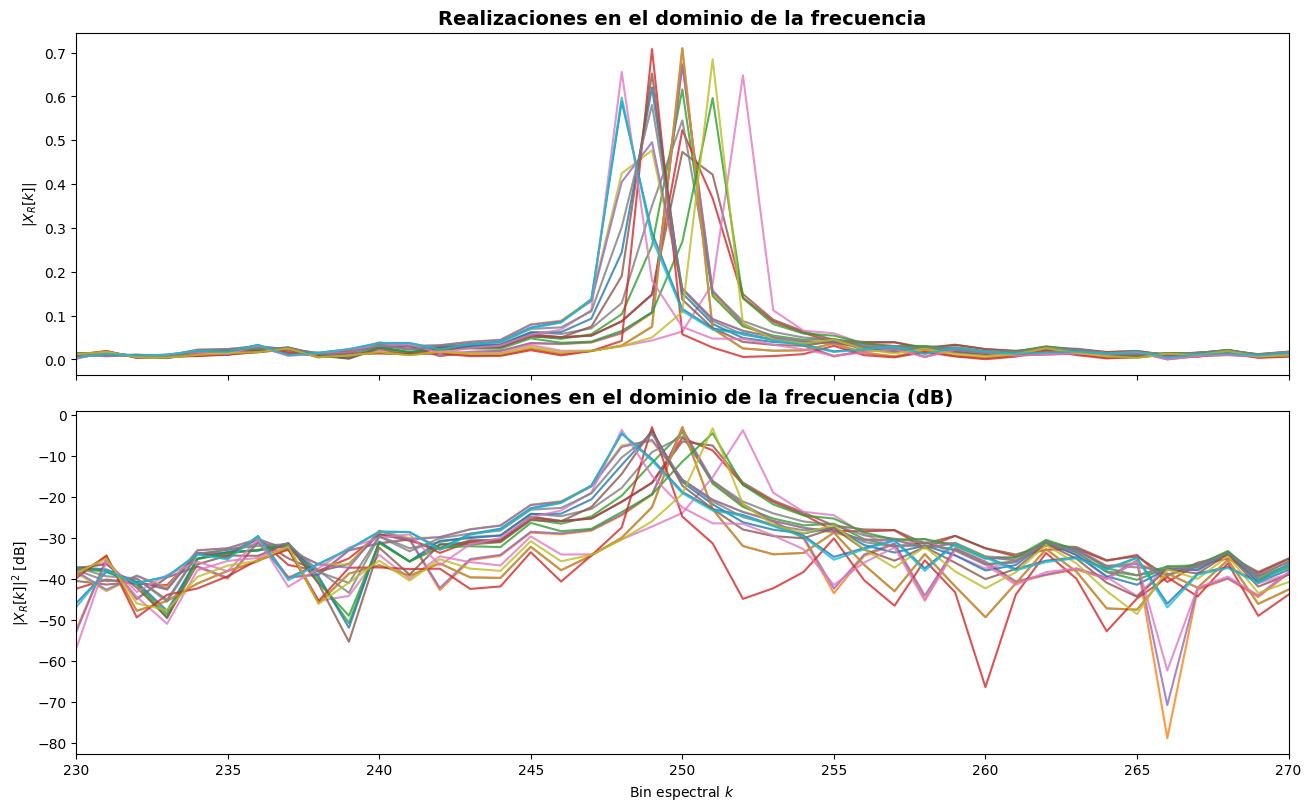

In [99]:
import seaborn as sns

fig, axs = plt.subplots(
    2, 1,
    figsize=(13, 8),
    sharex=True,
    constrained_layout=True
)

# =========================
# Dominio lineal
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=x_fft_abs[i, :],
        ax=axs[0],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[0].set_title(
    "Realizaciones en el dominio de la frecuencia",
    fontsize=14,
    weight='bold'
)

axs[0].set_ylabel(r"$|X_R[k]|$")

axs[0].set_xlim(N//4 - 20, N//4 + 20)

# =========================
# Dominio en dB
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=20 * np.log10(x_fft_abs[i, :] + 1e-12),
        ax=axs[1],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[1].set_title(
    "Realizaciones en el dominio de la frecuencia (dB)",
    fontsize=14,
    weight='bold'
)

axs[1].set_xlabel(r"Bin espectral $k$")
axs[1].set_ylabel(r"$|X_R[k]|^2$ [dB]")

axs[1].set_xlim(N//4 - 20, N//4 + 20)

plt.show()

Definimos el primer estimador, un estimador de energia:

$$
\hat{a}_1^{\,i} = \left| X_w^{\,i}(\Omega_0) \right| = \left| \mathcal{F}\{ x(n)\cdot w_i(n) \} \right|
$$

Siendo $w_i(n)$ la ventana, de la que todavia no hablamos nada. Todavia estamos usando la ventana implicita, que segun vimos en la TS4, genera el kernel de Dirichlet en frecuencia.

Este estimador intenta estimar, valga la redundancia, la energia de la señal obteniendo el valor del bin de $\Omega_0$. No es un buen estimador porque como ya vimos y graficamos, la potencia de la señal está en centrada en distintas frecuencias segun la realizacion gracias a la variable aleatoria que conforma $\Omega_1$ 

Vamos a graficar el histograma de 3 estimadores, uno que toma la energia de $\Omega_0$ como ya dijimos, pero despues otros dos que toman la energia en $\Omega_0 - 1$ y $\Omega_0 + 1$.

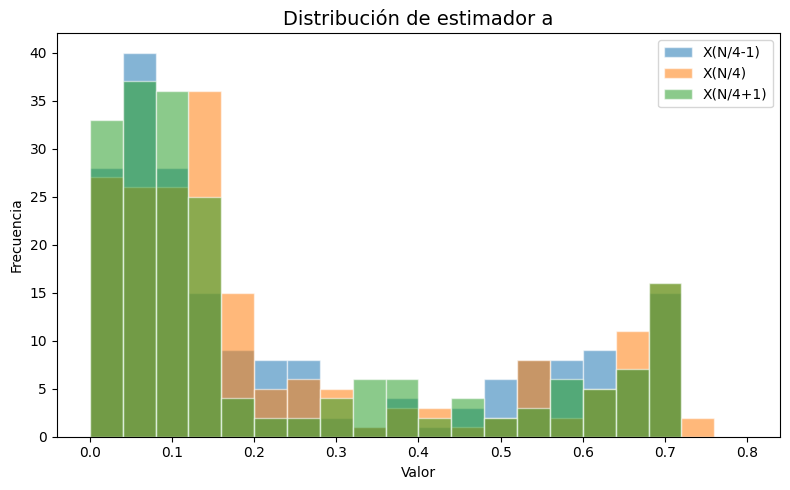

Media del estimador: 0.246
Varianza del estimador: 0.055
Sesgo del estimador: -0.461


In [100]:
estimador_a_1 = (x_fft_abs[:,int(N/4-1)])
estimador_a = (x_fft_abs[:,int(N/4)])
estimador_a1 = (x_fft_abs[:,int(N/4+1)])
plt.figure(figsize=(8, 5))
plt.hist(estimador_a_1, label="X(N/4-1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a, label="X(N/4)",bins = 20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.hist(estimador_a1, label="X(N/4+1)", bins=20, edgecolor='white', alpha=0.55, range=(0, .8))
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()

sesgo_a = np.mean(estimador_a) - np.sqrt(2)/2

print(f"Media del estimador: {np.mean(estimador_a):.3f}")
print(f"Varianza del estimador: {np.var(estimador_a):.3f}")
print(f"Sesgo del estimador: {sesgo_a:.3f}")

Vemos que la distribucion de los 3 estimadores son similares. Volvemos a tomar el estimador que mencionamos al principio ($X(\Omega_0)$) y le vamos a corregir el sesgo

Media del estimador: 0.707
Varianza del estimador: 0.055
Sesgo del estimador: 0.000


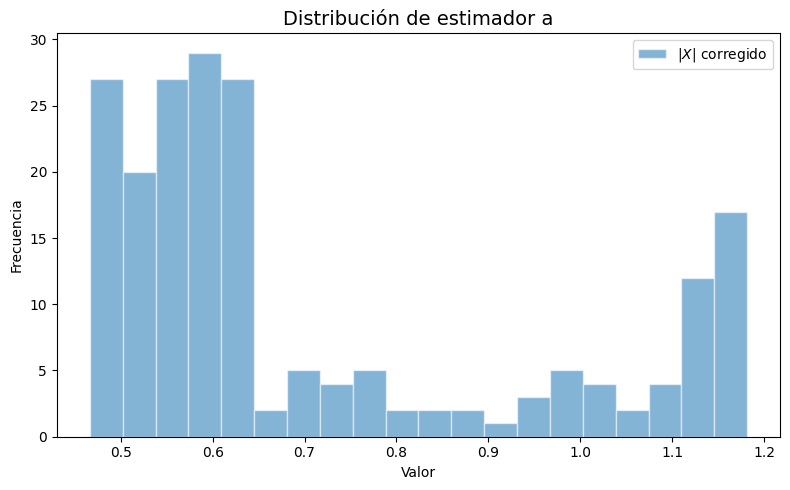

In [101]:
estimador_a_corregido = estimador_a - sesgo_a

print(f"Media del estimador: {np.mean(estimador_a_corregido):.3f}")
print(f"Varianza del estimador: {np.var(estimador_a_corregido):.3f}")
print(f"Sesgo del estimador: {np.mean(estimador_a_corregido) - np.sqrt(2)/2:.3f}")

plt.figure(figsize=(8, 5))
plt.hist(estimador_a_corregido, label="$|X|$ corregido", bins=20, edgecolor='white', alpha=0.55)
plt.title('Distribución de estimador a', fontsize=14)
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.legend()
plt.show()


Creamos una funcion para calcular el estimador y aplicar distintas ventanas de muestreo:

In [102]:
def calcular_estimador_a(x, N, ventana = None, eliminar_sesgo = True, correccion = np.sqrt(2)/2):
    if ventana != None:
        x_ventaneado = x * ventana(N)
    else:
        x_ventaneado = x

    x_fft = np.fft.fft(x_ventaneado, axis=1)
    x_fft_abs = np.abs(x_fft)/N

    estimador = x_fft_abs[:,int(N/4)]

    if eliminar_sesgo:
        sesgo = np.mean(estimador) - correccion
        estimador = estimador - sesgo

    return estimador

Vamos a usar las ventanas Hann, Blackmanharris y Flattop ademas de la rectangular.

### Ventana Hann

$$
w[n] =
\begin{cases}
0.5 \left(1 - \cos\left(\dfrac{2\pi n}{N-1}\right)\right), & 0 \le n \le N-1 \\
0, & \text{en otro caso}
\end{cases}
$$

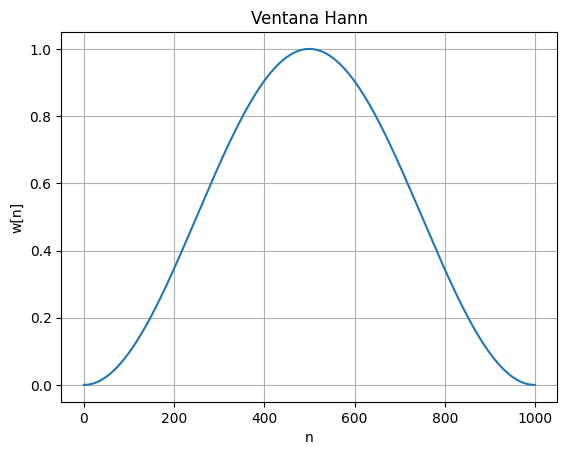

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import hann

w = hann(N)

plt.plot(w)
plt.title("Ventana Hann")
plt.xlabel("n")
plt.ylabel("w[n]")
plt.grid(True)
plt.show()

### Ventana Blackman-Harris

$$
w[n] =
\begin{cases}
a_0
- a_1 \cos\left(\dfrac{2\pi n}{N-1}\right)
+ a_2 \cos\left(\dfrac{4\pi n}{N-1}\right)
- a_3 \cos\left(\dfrac{6\pi n}{N-1}\right),
& 0 \le n \le N-1 \\
0, & \text{en otro caso}
\end{cases}
$$

$$
a_0 = 0.35875,\qquad
a_1 = 0.48829,\qquad
a_2 = 0.14128,\qquad
a_3 = 0.01168
$$

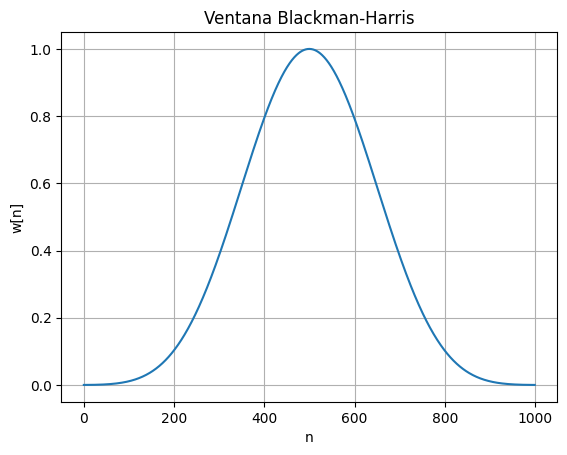

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import blackmanharris

w = blackmanharris(N)

plt.plot(w)
plt.title("Ventana Blackman-Harris")
plt.xlabel("n")
plt.ylabel("w[n]")
plt.grid(True)
plt.show()

### Ventana Flattop

$$
w[n] =
\begin{cases}
a_0
- a_1 \cos\left(\dfrac{2\pi n}{N-1}\right)
+ a_2 \cos\left(\dfrac{4\pi n}{N-1}\right)
- a_3 \cos\left(\dfrac{6\pi n}{N-1}\right)
+ a_4 \cos\left(\dfrac{8\pi n}{N-1}\right),
& 0 \le n \le N-1 \\
0, & \text{en otro caso}
\end{cases}
$$

$$
a_0 = 1,\qquad
a_1 = 1.93,\qquad
a_2 = 1.29,\qquad
a_3 = 0.388,\qquad
a_4 = 0.028
$$

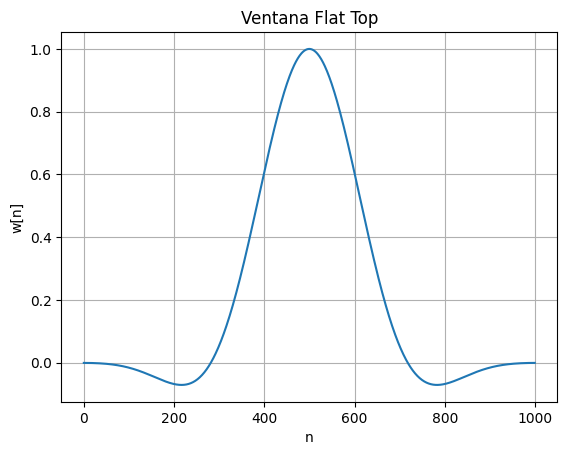

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import flattop

w = flattop(N)

plt.plot(w)
plt.title("Ventana Flat Top")
plt.xlabel("n")
plt.ylabel("w[n]")
plt.grid(True)
plt.show()

Ahora podemos ver la distribucion del estimador $\hat{a}_1^{\,i}$ para las distintas ventanas, y compararlas entre si:

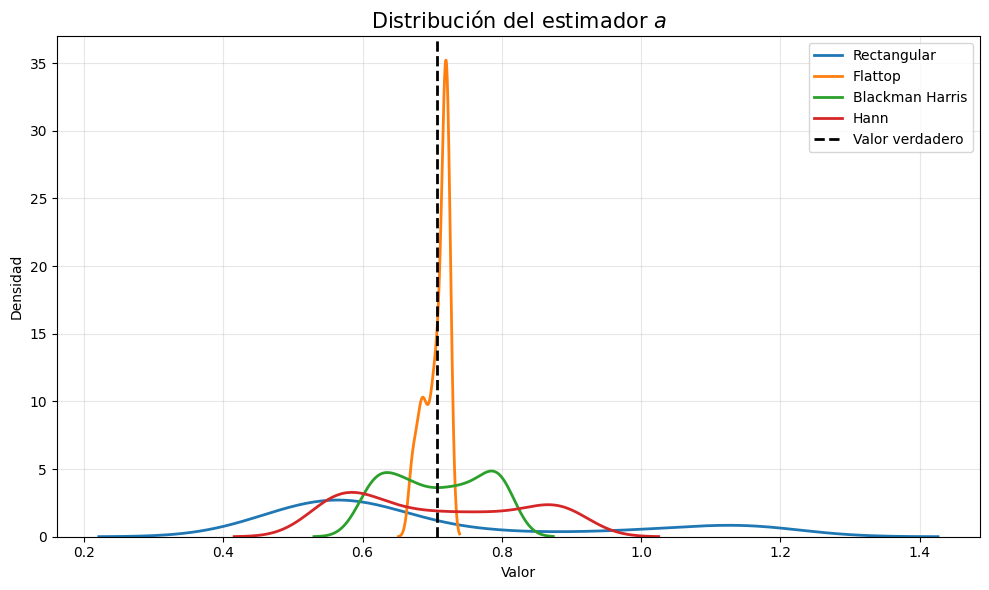

In [106]:
estimador_a_ft = calcular_estimador_a(x10db, N, flattop)
estimador_a_bmh = calcular_estimador_a(x10db, N, blackmanharris)
estimador_a_hann = calcular_estimador_a(x10db, N, hann)

import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_a_corregido,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_a_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_a_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_a_hann,
            linewidth=2,
            label='Hann')

plt.axvline(np.sqrt(2)/2,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title('Distribución del estimador $a$', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Tambien podemos hacer comparar los estimadores usando violinplots:

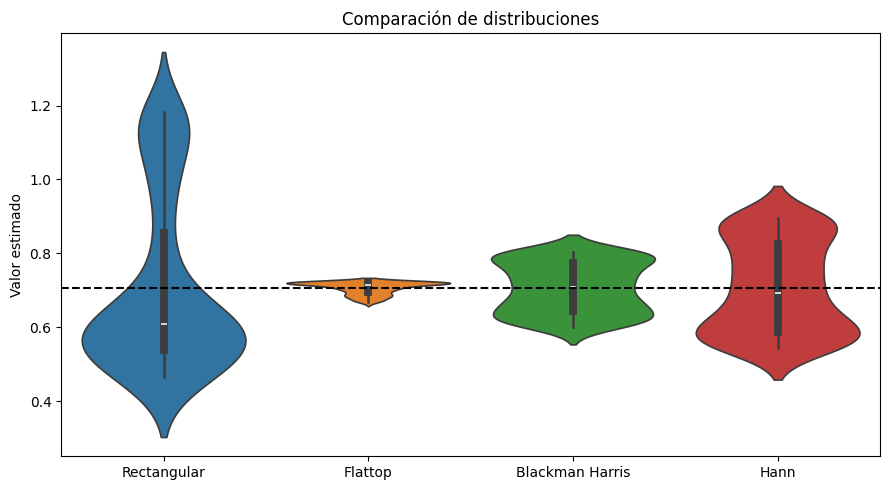

In [107]:
datos = [
    estimador_a_corregido,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

plt.figure(figsize=(9, 5))

sns.violinplot(data=datos)

plt.xticks(range(4), labels)
plt.axhline(np.sqrt(2)/2,
            linestyle='--',
            color='black')

plt.ylabel('Valor estimado')
plt.title('Comparación de distribuciones')

plt.tight_layout()
plt.show()

Se ve con gran claridad que para este estimador la ventana de Flattop se destaca muchísimo por sobre las demás. Además de tener una varianza mucho menor, la mediana de la distribución es muy similar al valor esperado del estimador. Podemos comparar los datos:

In [108]:
datos = [
    estimador_a_corregido,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

print(f"{'Ventana':<20} {'Media':>12} {'Varianza':>12} {'Mediana':>12}")
print("-" * 60)

for label, data in zip(labels, datos):
    media = np.mean(data)
    varianza = np.var(data)
    mediana = np.median(data)

    print(f"{label:<20} {media:>12.4f} {varianza:>12.4f} {mediana:>12.4f}")

Ventana                     Media     Varianza      Mediana
------------------------------------------------------------
Rectangular                0.7071       0.0552       0.6079
Flattop                    0.7071       0.0003       0.7147
Blackman Harris            0.7071       0.0046       0.7078
Hann                       0.7071       0.0153       0.6918


Por supuesto la media en cada ventana es la misma, ya que la estamos corrigiendo cuando corregimos el sesgo.

Se puede concluir que para este estimador conviene mucho usar una ventana Flattop.

## Experimento de $\hat{a}_1^{\,i}$ para una SNR de 3 dB

Generamos nuestra nueva señal:

In [109]:
N = 1000
fs = 1000
realizaciones = 200

fr = np.random.uniform(-2, 2, realizaciones)
pot_ruido_db = -3
na, _ = pds_awgn(N, fs=1000, potencia_W=10**(pot_ruido_db/10))
Omega0 = np.pi / 2
Omega1 = Omega0 + fr * (2*np.pi/N)
Omega1 = Omega1.reshape((realizaciones,1))

ang =  Omega1 * np.arange(N).reshape((1,N))
x = np.sqrt(2) * np.sin(ang) + na

x3db = x

x_fft = np.fft.fft(x, axis=1)
x_fft_abs = np.abs(x_fft)/N

Podemos graficar las realizaciones:

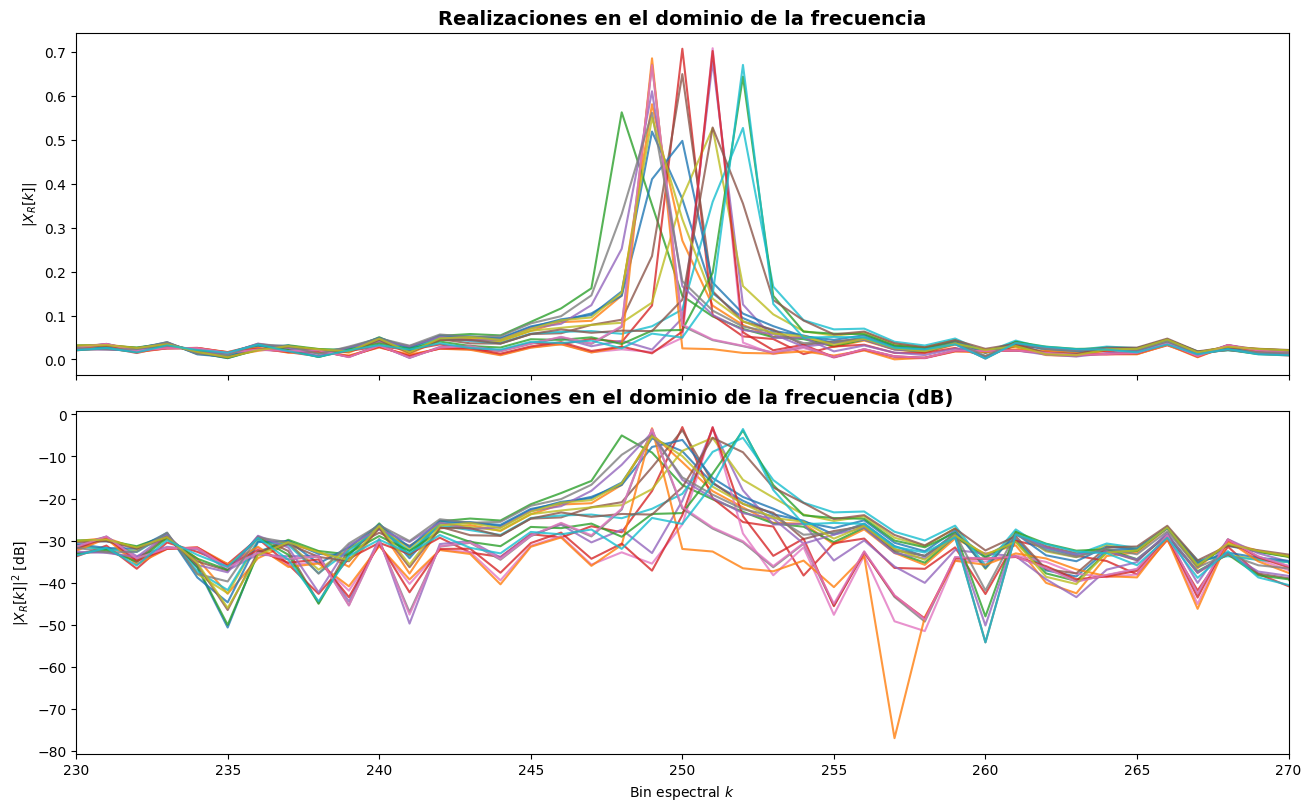

In [110]:
import seaborn as sns

fig, axs = plt.subplots(
    2, 1,
    figsize=(13, 8),
    sharex=True,
    constrained_layout=True
)

# =========================
# Dominio lineal
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=x_fft_abs[i, :],
        ax=axs[0],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[0].set_title(
    "Realizaciones en el dominio de la frecuencia",
    fontsize=14,
    weight='bold'
)

axs[0].set_ylabel(r"$|X_R[k]|$")

axs[0].set_xlim(N//4 - 20, N//4 + 20)

# =========================
# Dominio en dB
# =========================
for i in range(20):
    sns.lineplot(
        x=x_fft_abs.shape[1] * [0] + np.arange(x_fft_abs.shape[1]),
        y=20 * np.log10(x_fft_abs[i, :] + 1e-12),
        ax=axs[1],
        linewidth=1.5,
        alpha=0.8,
        legend=False
    )

axs[1].set_title(
    "Realizaciones en el dominio de la frecuencia (dB)",
    fontsize=14,
    weight='bold'
)

axs[1].set_xlabel(r"Bin espectral $k$")
axs[1].set_ylabel(r"$|X_R[k]|^2$ [dB]")

axs[1].set_xlim(N//4 - 20, N//4 + 20)

plt.show()

Generamos los nuevos estimadores:

In [111]:
estimador_a_rectangular = calcular_estimador_a(x3db, N, None)
estimador_a_ft = calcular_estimador_a(x3db, N, flattop)
estimador_a_bmh = calcular_estimador_a(x3db, N, blackmanharris)
estimador_a_hann = calcular_estimador_a(x3db, N, hann)

Graficamos las distribuciones:

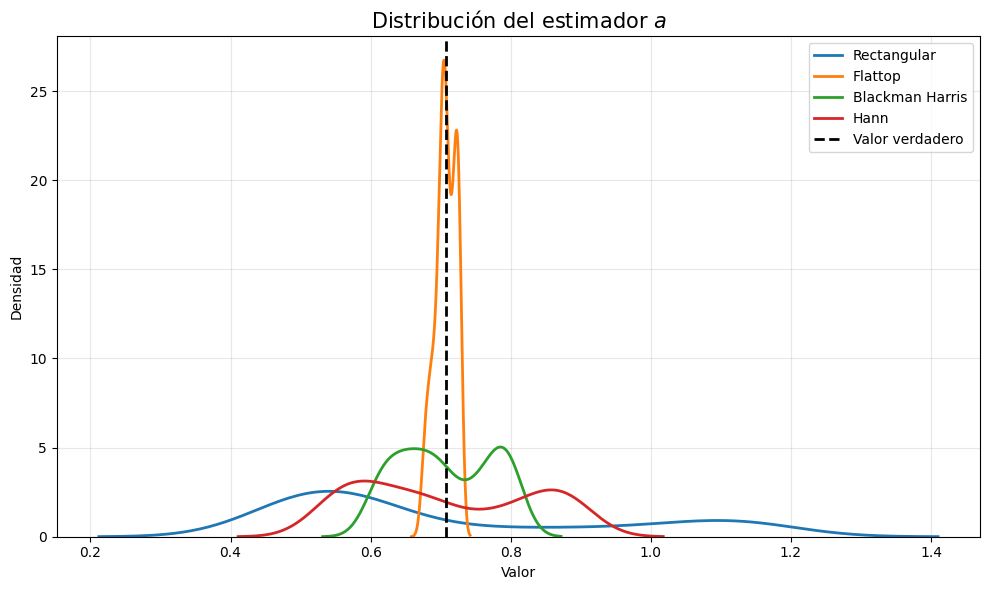

In [112]:
plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_a_rectangular,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_a_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_a_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_a_hann,
            linewidth=2,
            label='Hann')

plt.axvline(np.sqrt(2)/2,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title('Distribución del estimador $a$', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Generamos los violinplots:

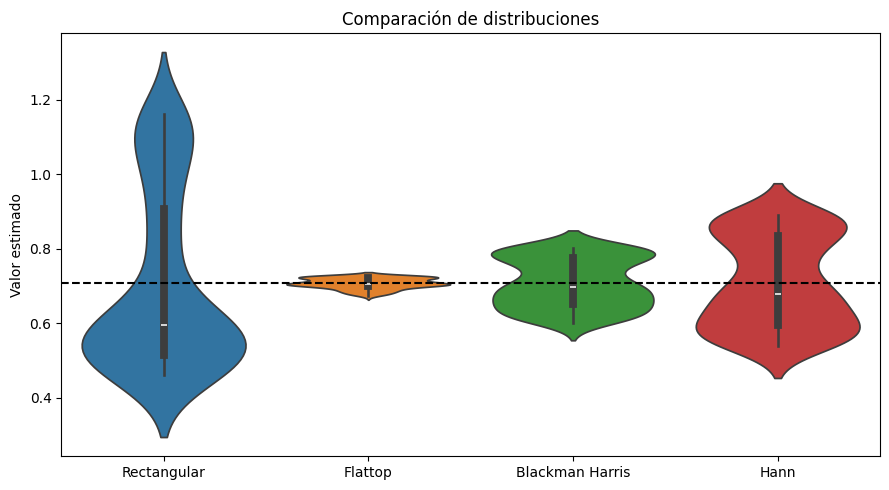

In [113]:
datos = [
    estimador_a_rectangular,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

plt.figure(figsize=(9, 5))

sns.violinplot(data=datos)

plt.xticks(range(4), labels)
plt.axhline(np.sqrt(2)/2,
            linestyle='--',
            color='black')

plt.ylabel('Valor estimado')
plt.title('Comparación de distribuciones')

plt.tight_layout()
plt.show()

Generamos la tabla de comparacion:

In [114]:
datos = [
    estimador_a_rectangular,
    estimador_a_ft,
    estimador_a_bmh,
    estimador_a_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

print(f"{'Ventana':<20} {'Media':>12} {'Varianza':>12} {'Mediana':>12}")
print("-" * 60)

for label, data in zip(labels, datos):
    media = np.mean(data)
    varianza = np.var(data)
    mediana = np.median(data)

    print(f"{label:<20} {media:>12.4f} {varianza:>12.4f} {mediana:>12.4f}")

Ventana                     Media     Varianza      Mediana
------------------------------------------------------------
Rectangular                0.7071       0.0567       0.5964
Flattop                    0.7071       0.0002       0.7064
Blackman Harris            0.7071       0.0043       0.6967
Hann                       0.7071       0.0149       0.6789


Empeorar la SNR de la señal **no empeoró** la varianza de los estimadores.

## Experimento de estimacion frecuencial $\hat{\Omega}_1^i$ con SNR de 10dB

$$
\hat{\Omega}_1^i = \arg \max_{\Omega} \left\{ \left| X_w^i(\Omega) \right| \right\}
$$

Se generara un estimador de frecuencia. Se buscara el bin frecuencial mas alto para definirla. Volveremos a usar las variales $x10db$ y $x3db$ generadas en los experimentos anteriores.

Graficamos una realizacion para ilustrar:

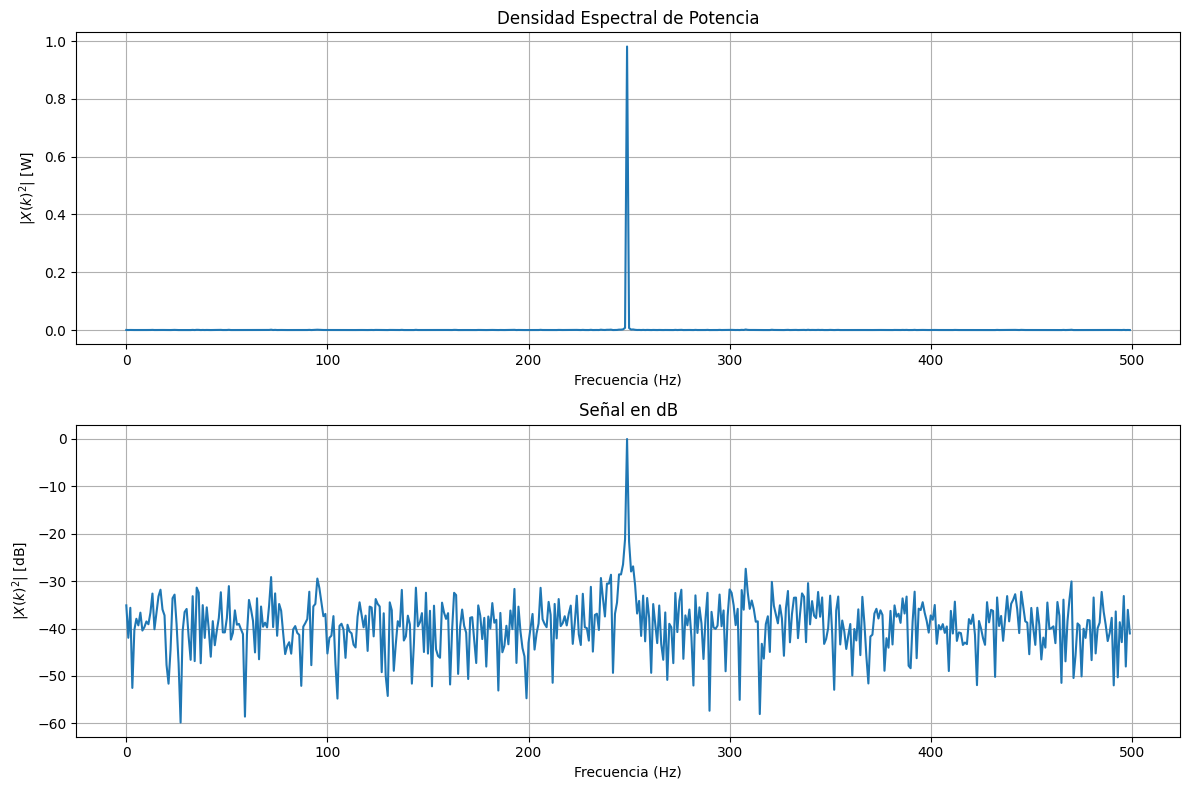

In [115]:
_, _ = plot_psd_señal(x10db[-1,:], fs, N, type="line")

Primero limitamos el espectro a la mitad y despues buscamos el indice de mayor magnitud en cada una de las realizaciones.

In [116]:
def calcular_estimador_omega(x, N, ventana = None, eliminar_sesgo = True, correccion = 250, zerop = False):
    if ventana != None:
        x_ventaneado = x * ventana(N)
    else:
        x_ventaneado = x

    muestras = N
    if zerop != False:
        muestras = muestras + zerop

    x_ventaneado_fft = np.fft.fft(x_ventaneado, axis=1, n=muestras)
    x_ventaneado_fft = x_ventaneado_fft[:, 0:muestras//2]
    x_ventaneado_fft_abs = np.abs(x_ventaneado_fft)/muestras

    e_omega = np.argmax(x_ventaneado_fft_abs, axis=1)

    if eliminar_sesgo:
        sesgo = np.mean(e_omega) - correccion
        e_omega = e_omega - sesgo

    return e_omega

estimador_omega = calcular_estimador_omega(x10db, N, eliminar_sesgo=False)

print(f"Media del estimador: {np.mean(estimador_omega):.3f}")
print(f"Varianza del estimador: {np.var(estimador_omega):.3f}")
print(f"Sesgo del estimador: {np.mean(estimador_omega) - (fs/(2*np.pi))*Omega0:.3f}")

Media del estimador: 249.890
Varianza del estimador: 1.578
Sesgo del estimador: -0.110


A priori vemos que parece que tenemos muy poca varianza en el estimador. Igualmente hay que tener en cuenta que es relativamente poca la cantidad de ruido que hay en $\Omega_1$.

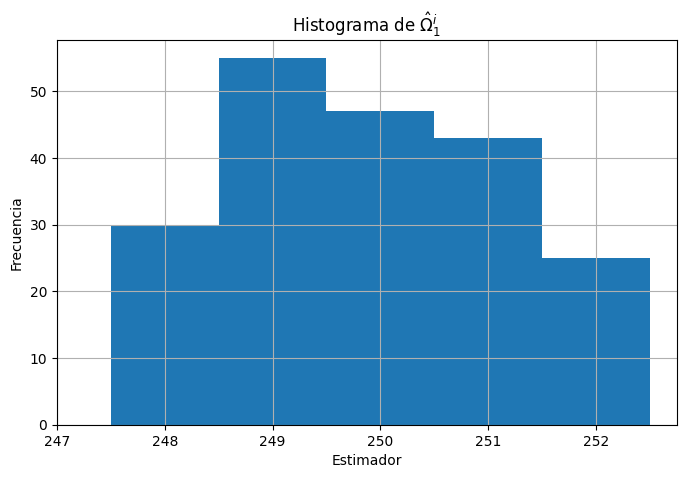

In [117]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange(247.5, 252.5 + 1, 1)  # bins centrados en enteros

plt.figure(figsize=(8, 5))
plt.hist(estimador_omega, bins=bins)

plt.xticks(np.arange(247, 253, 1))

plt.xlabel(r'Estimador')
plt.ylabel('Frecuencia')
plt.title(r'Histograma de $\hat{\Omega}_1^i$')
plt.grid(True)

plt.show()

Ahora hacemos el experimento para las mimas ventanas que antes:

In [118]:
estimador_omega_rectangular = calcular_estimador_omega(x10db, N, None)
estimador_omega_ft = calcular_estimador_omega(x10db, N, flattop)
estimador_omega_bmh = calcular_estimador_omega(x10db, N, blackmanharris)
estimador_omega_hann = calcular_estimador_omega(x10db, N, hann)

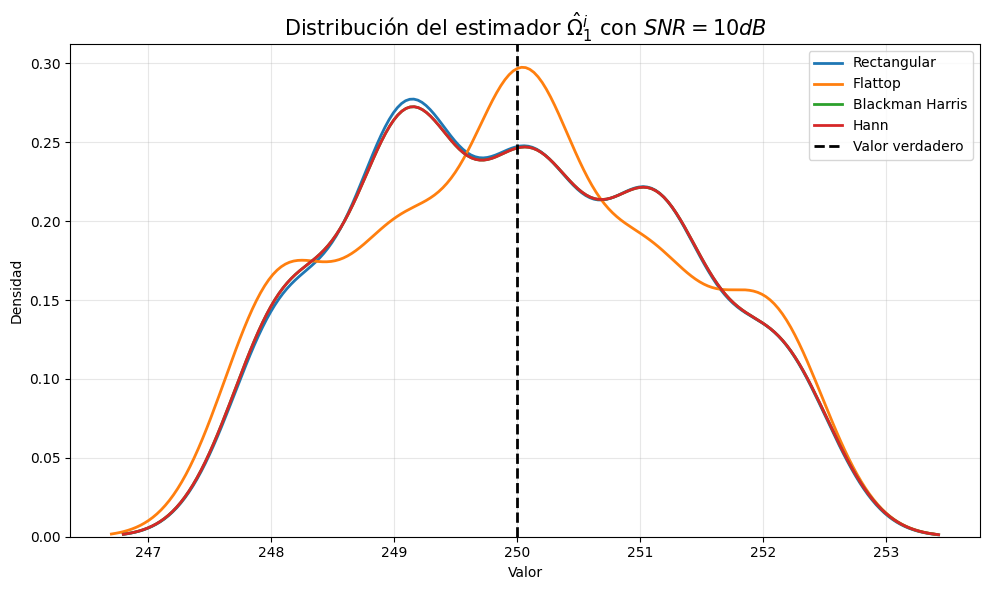

In [119]:
plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_omega_rectangular,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_omega_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_omega_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_omega_hann,
            linewidth=2,
            label='Hann')

plt.axvline(250,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title(r'Distribución del estimador $\hat{\Omega}_1^i$ con $SNR=10dB$', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Vemos en una tabla los datos (con sesgo corregido):

In [120]:
datos = [
    estimador_omega_rectangular,
    estimador_omega_ft,
    estimador_omega_bmh,
    estimador_omega_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

print(f"{'Ventana':<20} {'Media':>12} {'Varianza':>12} {'Mediana':>12}")
print("-" * 60)

for label, data in zip(labels, datos):
    media = np.mean(data)
    varianza = np.var(data)
    mediana = np.median(data)

    print(f"{label:<20} {media:>12.4f} {varianza:>12.4f} {mediana:>12.4f}")

Ventana                     Media     Varianza      Mediana
------------------------------------------------------------
Rectangular              250.0000       1.5779     250.1100
Flattop                  250.0000       1.6820     250.0550
Blackman Harris          250.0000       1.5918     250.1150
Hann                     250.0000       1.5918     250.1150


A diferencia del estimador de energía, no vemos grandes diferencias entre las diferentes ventanas para el estimador de frecuencia.

## Experimento de estimacion frecuencial $\hat{\Omega}_1^i$ con SNR de 3dB

$$
\hat{\Omega}_1^i = \arg \max_{\Omega} \left\{ \left| X_w^i(\Omega) \right| \right\}
$$

Antes de hacer el experimento, lo que uno esperaría es que la SNR no interfiera demasiado en la estimacion de frecuencia. Vimos que para el estimador de energía (según mi intuición el más sensible a ruido) no había grandes diferencias, así que espero que acá tampoco las haya.

Usamos la variable $x3db$ previamente definida.

In [121]:
estimador_omega_rectangular = calcular_estimador_omega(x3db, N, None)
estimador_omega_ft = calcular_estimador_omega(x3db, N, flattop)
estimador_omega_bmh = calcular_estimador_omega(x3db, N, blackmanharris)
estimador_omega_hann = calcular_estimador_omega(x3db, N, hann)

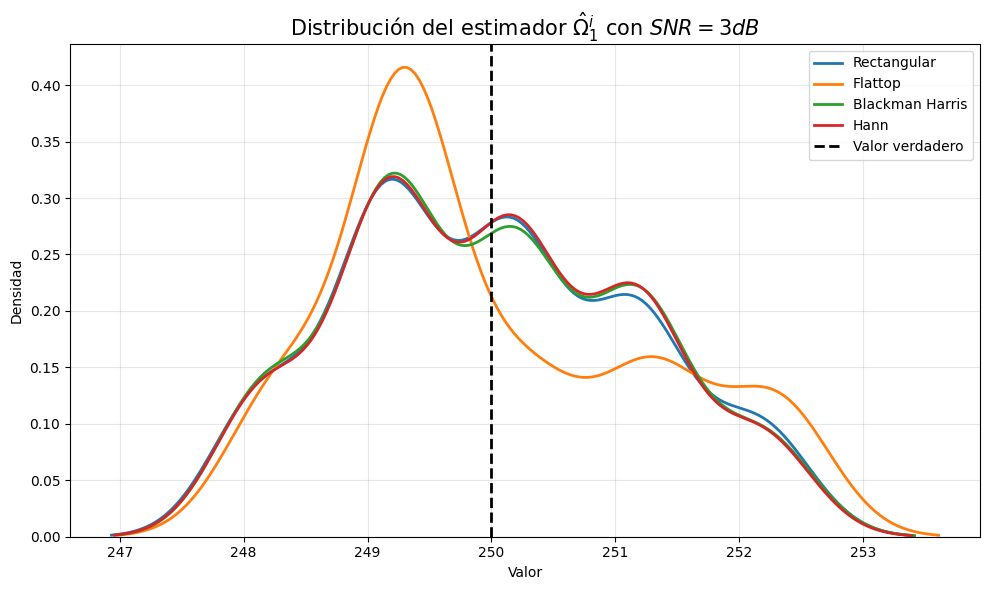

In [122]:
plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_omega_rectangular,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_omega_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_omega_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_omega_hann,
            linewidth=2,
            label='Hann')

plt.axvline(250,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title(r'Distribución del estimador $\hat{\Omega}_1^i$ con $SNR=3dB$', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Vemos en una tabla los datos (con sesgo corregido):

In [123]:
datos = [
    estimador_omega_rectangular,
    estimador_omega_ft,
    estimador_omega_bmh,
    estimador_omega_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

print(f"{'Ventana':<20} {'Media':>12} {'Varianza':>12} {'Mediana':>12}")
print("-" * 60)

for label, data in zip(labels, datos):
    media = np.mean(data)
    varianza = np.var(data)
    mediana = np.median(data)

    print(f"{label:<20} {media:>12.4f} {varianza:>12.4f} {mediana:>12.4f}")

Ventana                     Media     Varianza      Mediana
------------------------------------------------------------
Rectangular              250.0000       1.3978     250.1650
Flattop                  250.0000       1.5800     249.3000
Blackman Harris          250.0000       1.3839     250.1900
Hann                     250.0000       1.3644     250.1750


De nuevo, no vemos grandes diferencias entre las distintas ventanas elegidas para este estimador. Lo único a considerar es que aumento (un poco) la varianza en cada uno de los estimadores, independientemente de la ventana elegida.

# Resumen de datos de los estimadores

Calculamos todos los estimadores juntos. No eliminamos el sesgo porque es un parámetro a mostrar en la tabla.

In [124]:
# Calculos para 10 dB

estimador_a_rectangular_10dB = calcular_estimador_a(x10db, N, None, eliminar_sesgo=False)
estimador_a_ft_10dB = calcular_estimador_a(x10db, N, flattop, eliminar_sesgo=False)
estimador_a_bmh_10dB = calcular_estimador_a(x10db, N, blackmanharris, eliminar_sesgo=False)
estimador_a_hann_10dB = calcular_estimador_a(x10db, N, hann, eliminar_sesgo=False)



estimador_omega_rectangular_10dB = calcular_estimador_omega(x10db, N, None, eliminar_sesgo=False)
estimador_omega_ft_10dB = calcular_estimador_omega(x10db, N, flattop, eliminar_sesgo=False)
estimador_omega_bmh_10dB = calcular_estimador_omega(x10db, N, blackmanharris, eliminar_sesgo=False)
estimador_omega_hann_10dB = calcular_estimador_omega(x10db, N, hann, eliminar_sesgo=False)


# Calculos para 3 dB

estimador_a_rectangular_3dB = calcular_estimador_a(x3db, N, None, eliminar_sesgo=False)
estimador_a_ft_3dB = calcular_estimador_a(x3db, N, flattop, eliminar_sesgo=False)
estimador_a_bmh_3dB = calcular_estimador_a(x3db, N, blackmanharris, eliminar_sesgo=False)
estimador_a_hann_3dB = calcular_estimador_a(x3db, N, hann, eliminar_sesgo=False)


estimador_omega_rectangular_3dB = calcular_estimador_omega(x3db, N, None, eliminar_sesgo=False)
estimador_omega_ft_3dB = calcular_estimador_omega(x3db, N, flattop, eliminar_sesgo=False)
estimador_omega_bmh_3dB = calcular_estimador_omega(x3db, N, blackmanharris, eliminar_sesgo=False)
estimador_omega_hann_3dB = calcular_estimador_omega(x3db, N, hann, eliminar_sesgo=False)

In [125]:
import numpy as np
import pandas as pd

# Valores verdaderos
a_real = np.sqrt(2) / 2
omega_real = 250

# =========================================
# TABLA 10 dB
# =========================================

filas_10db = []

estimadores_10db = {
    "Rectangular": {
        "A": estimador_a_rectangular_10dB,
        "Omega": estimador_omega_rectangular_10dB
    },
    "Flattop": {
        "A": estimador_a_ft_10dB,
        "Omega": estimador_omega_ft_10dB
    },
    "Blackman-Harris": {
        "A": estimador_a_bmh_10dB,
        "Omega": estimador_omega_bmh_10dB
    },
    "Hann": {
        "A": estimador_a_hann_10dB,
        "Omega": estimador_omega_hann_10dB
    }
}

for ventana, datos in estimadores_10db.items():

    filas_10db.append([
        ventana,
        np.mean(datos["A"]) - a_real,
        np.var(datos["A"]),
        np.mean(datos["Omega"]) - omega_real,
        np.var(datos["Omega"])
    ])

tabla_10db = pd.DataFrame(
    filas_10db,
    columns=[
        "Ventana",
        "Sesgo A",
        "Varianza A",
        "Sesgo Ω",
        "Varianza Ω"
    ]
)

tabla_10db = tabla_10db.set_index("Ventana")

print("========== 10 dB ==========")
display(tabla_10db.style.format("{:.6f}"))


# =========================================
# TABLA 3 dB
# =========================================

filas_3db = []

estimadores_3db = {
    "Rectangular": {
        "A": estimador_a_rectangular_3dB,
        "Omega": estimador_omega_rectangular_3dB
    },
    "Flattop": {
        "A": estimador_a_ft_3dB,
        "Omega": estimador_omega_ft_3dB
    },
    "Blackman-Harris": {
        "A": estimador_a_bmh_3dB,
        "Omega": estimador_omega_bmh_3dB
    },
    "Hann": {
        "A": estimador_a_hann_3dB,
        "Omega": estimador_omega_hann_3dB
    }
}

for ventana, datos in estimadores_3db.items():

    filas_3db.append([
        ventana,
        np.mean(datos["A"]) - a_real,
        np.var(datos["A"]),
        np.mean(datos["Omega"]) - omega_real,
        np.var(datos["Omega"])
    ])

tabla_3db = pd.DataFrame(
    filas_3db,
    columns=[
        "Ventana",
        "Sesgo A",
        "Varianza A",
        "Sesgo Ω",
        "Varianza Ω"
    ]
)

tabla_3db = tabla_3db.set_index("Ventana")

print("========== 3 dB ==========")
display(tabla_3db.style.format("{:.6f}"))

========== 10 dB ==========


,Sesgo A,Varianza A,Sesgo Ω,Varianza Ω
Ventana,,,,
Rectangular,-0.460623,0.055219,-0.110000,1.577900
Flattop,-0.569482,0.000271,-0.055000,1.681975
Blackman-Harris,-0.547564,0.004600,-0.115000,1.591775
Hann,-0.538859,0.015270,-0.115000,1.591775


========== 3 dB ==========


,Sesgo A,Varianza A,Sesgo Ω,Varianza Ω
Ventana,,,,
Rectangular,-0.439511,0.056733,-0.165000,1.397775
Flattop,-0.567537,0.000203,-0.300000,1.580000
Blackman-Harris,-0.540812,0.004336,-0.190000,1.383900
Hann,-0.527472,0.014859,-0.175000,1.364375


## Experimento con zero-padding

Recalcularemos el estimador Omega pero ahora usando zero-padding en la fft.

Con la misma funcion que antes, agregamos el zero-padding. Dividimos por 10 al final reescalar a la frecuencia original.

In [137]:
estimador_omega_rectangular_zp = calcular_estimador_omega(x10db, N, None, zerop=N*14, eliminar_sesgo=False) / 15 #Normalizo
estimador_omega_rectangular_nzp = calcular_estimador_omega(x10db, N, None, zerop=False, eliminar_sesgo=False)

Podemos graficar la densidad de probabilidad:

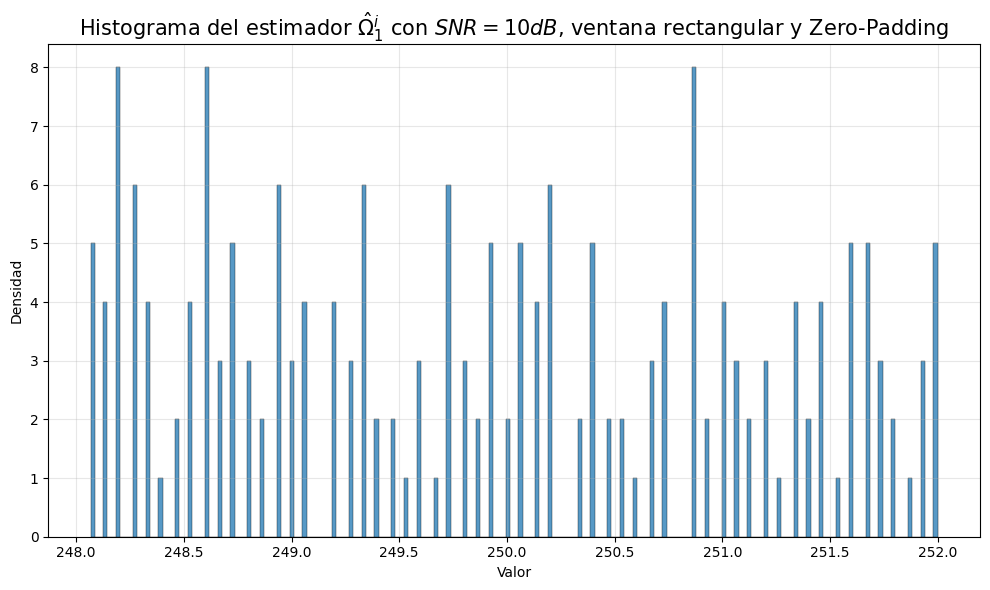

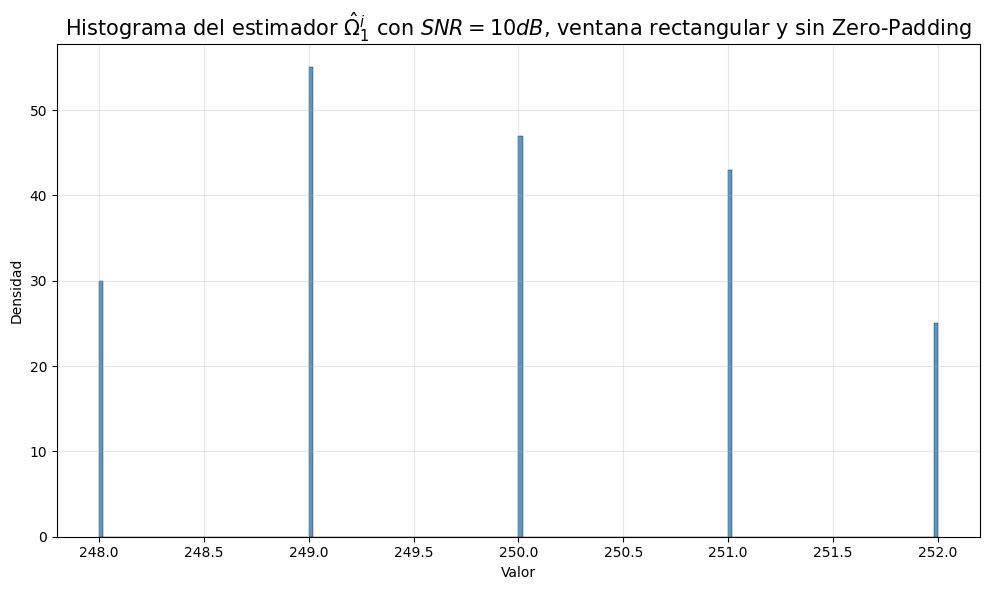

In [138]:
plt.figure(figsize=(10, 6))

bins = np.arange(247.75, 252.75, 0.5)  # bins centrados en enteros
bins = 200

sns.histplot(estimador_omega_rectangular_zp, bins=bins)

plt.title(r'Histograma del estimador $\hat{\Omega}_1^i$ con $SNR=10dB$, ventana rectangular y Zero-Padding', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


plt.figure(figsize=(10, 6))

sns.histplot(estimador_omega_rectangular_nzp, bins=bins)

plt.title(r'Histograma del estimador $\hat{\Omega}_1^i$ con $SNR=10dB$, ventana rectangular y sin Zero-Padding', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Claramente se nota que aumenta la resolucion espectral como vimos en la TS anterior. Con ese aumento de la resolucion espectral se esperaria que baje la varianza del estimador.

Vemos varianza y sesgo de los estimadores:

In [144]:
print("Con zero-padding:")
print(f"Media con zero-padding: {np.mean(estimador_omega_rectangular_zp):.3f}")
print(f"Varianza con zero-padding: {np.var(estimador_omega_rectangular_zp):.3f}")
print(f"Sesgo con zero-padding: {np.mean(estimador_omega_rectangular_zp) - 250:.3f}")

print("\n\n\nSin zero-padding:")
print(f"Media sin zero-padding: {np.mean(estimador_omega_rectangular_nzp):.3f}")
print(f"Varianza sin zero-padding: {np.var(estimador_omega_rectangular_nzp):.3f}")
print(f"Sesgo sin zero-padding: {np.mean(estimador_omega_rectangular_nzp) - 250:.3f}")

Con zero-padding:
Media con zero-padding: 249.888
Varianza con zero-padding: 1.443
Sesgo con zero-padding: -0.112



Sin zero-padding:
Media sin zero-padding: 249.890
Varianza sin zero-padding: 1.578
Sesgo sin zero-padding: -0.110


Vemos que con el zero padding baja la varianza del estimador de frecuencia.

## Otros estimadores

Vamos a definir un nuevo estimador de energia, combinando ambos estimadores usados anteriormente.

Se estimara la energia usando el bin de mayor energia, no un bin fijo donde suponemos que esta la señal.

$$
\hat{b}^{\,i} = \left| X_w^{\,i}(\arg \max_{\Omega} \left\{ \left| X_w^i(\Omega) \right| \right\}) \right|
$$


Empezamos usando la señal de 10d dB de SNR.

In [149]:
def calcular_estimador_b(x, N, ventana = None, eliminar_sesgo = True, correccion = np.sqrt(2)/2, zerop = False):
    if ventana != None:
        x_ventaneado = x * ventana(N)
    else:
        x_ventaneado = x

    muestras = N
    if zerop != False:
        muestras = muestras + zerop

    x_ventaneado_fft = np.fft.fft(x_ventaneado, axis=1, n=muestras)
    x_ventaneado_fft = x_ventaneado_fft[:, 0:muestras//2]
    x_ventaneado_fft_abs = np.abs(x_ventaneado_fft)/muestras

    omega = np.argmax(x_ventaneado_fft_abs, axis=1)
    
    estimador = x_ventaneado_fft_abs[np.arange(len(omega)), omega]

    if eliminar_sesgo:
        sesgo = np.mean(estimador) - correccion
        estimador = estimador - sesgo

    return estimador


estimador_b_rectangular = calcular_estimador_b(x10db, N, None)
estimador_b_ft = calcular_estimador_b(x10db, N, flattop)
estimador_b_bmh = calcular_estimador_b(x10db, N, blackmanharris)
estimador_b_hann = calcular_estimador_b(x10db, N, hann)

Podemos ver la distribucion del estimador para las distinta ventanas:

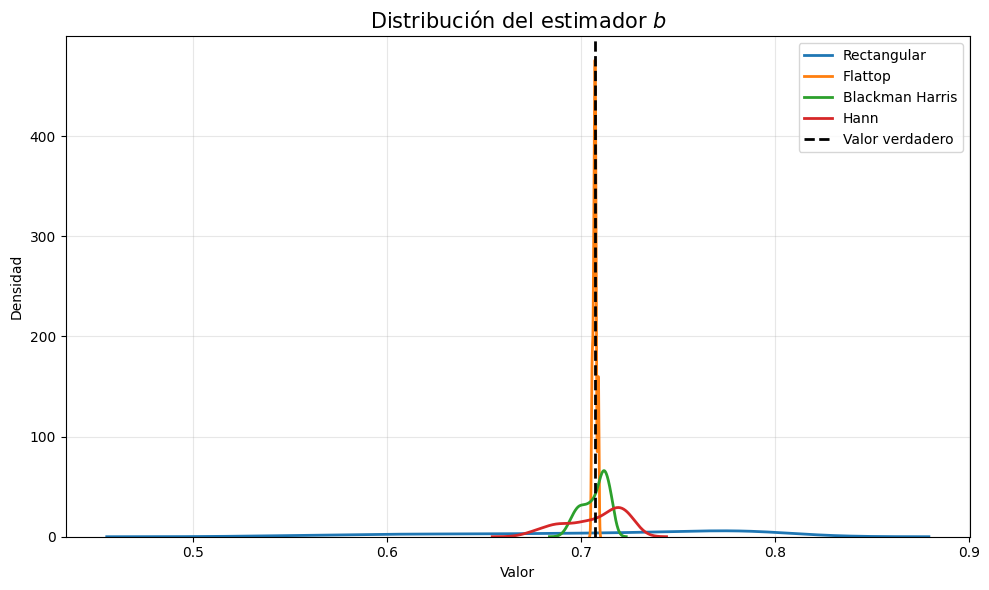

In [ ]:
plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_b_rectangular,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_b_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_b_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_b_hann,
            linewidth=2,
            label='Hann')

plt.axvline(np.sqrt(2)/2,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title('Distribución del estimador $b$ con SNR = 10 dB', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

Como se nos va de escala por la muy baja varianza de la ventana flattop, graficamos los violinplots:

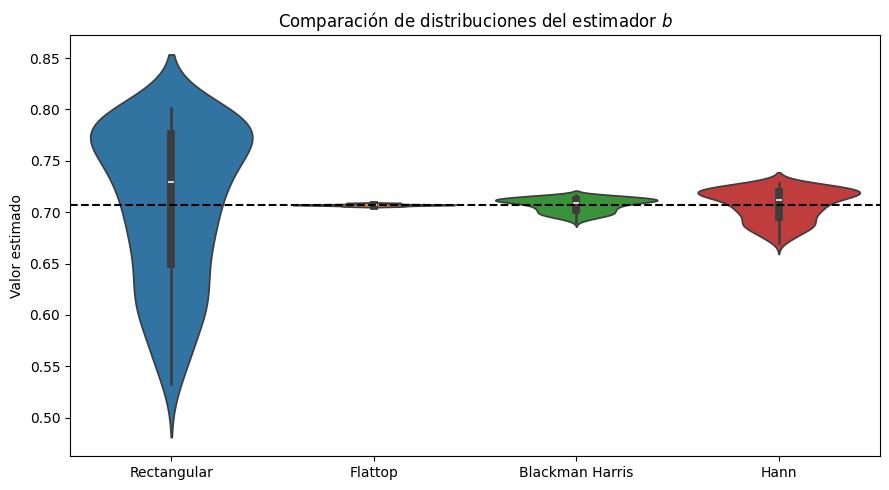

In [ ]:
datos = [
    estimador_b_rectangular,
    estimador_b_ft,
    estimador_b_bmh,
    estimador_b_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

plt.figure(figsize=(9, 5))

sns.violinplot(data=datos)

plt.xticks(range(4), labels)
plt.axhline(np.sqrt(2)/2,
            linestyle='--',
            color='black')

plt.ylabel('Valor estimado')
plt.title('Comparación de distribuciones del estimador $b$ con SNR = 10 dB')

plt.tight_layout()
plt.show()

Podemos comparar con el estimador $a$, para las mismas ventanas:

In [152]:
estimador_a_rectangular = calcular_estimador_a(x10db, N, None)
estimador_a_ft = calcular_estimador_a(x10db, N, flattop)
estimador_a_bmh = calcular_estimador_a(x10db, N, blackmanharris)
estimador_a_hann = calcular_estimador_a(x10db, N, hann)

In [153]:
import numpy as np
import pandas as pd

tabla_varianzas = pd.DataFrame(
    {
        "Rectangular": [
            np.var(estimador_a_rectangular),
            np.var(estimador_b_rectangular),
        ],
        "Flattop": [
            np.var(estimador_a_ft),
            np.var(estimador_b_ft),
        ],
        "Blackman-Harris": [
            np.var(estimador_a_bmh),
            np.var(estimador_b_bmh),
        ],
        "Hann": [
            np.var(estimador_a_hann),
            np.var(estimador_b_hann),
        ],
    },
    index=["Estimador A", "Estimador B"]
)

print(tabla_varianzas)

             Rectangular       Flattop  Blackman-Harris      Hann
Estimador A     0.055219  2.714681e-04         0.004600  0.015270
Estimador B     0.005547  9.040208e-07         0.000043  0.000231


Ahora repetimos el experimento para una señal de 3 dB de SNR.

In [155]:
estimador_b_rectangular = calcular_estimador_b(x3db, N, None)
estimador_b_ft = calcular_estimador_b(x3db, N, flattop)
estimador_b_bmh = calcular_estimador_b(x3db, N, blackmanharris)
estimador_b_hann = calcular_estimador_b(x3db, N, hann)
estimador_a_rectangular = calcular_estimador_a(x3db, N, None)
estimador_a_ft = calcular_estimador_a(x3db, N, flattop)
estimador_a_bmh = calcular_estimador_a(x3db, N, blackmanharris)
estimador_a_hann = calcular_estimador_a(x3db, N, hann)

Vemos las nuevas distribuciones:

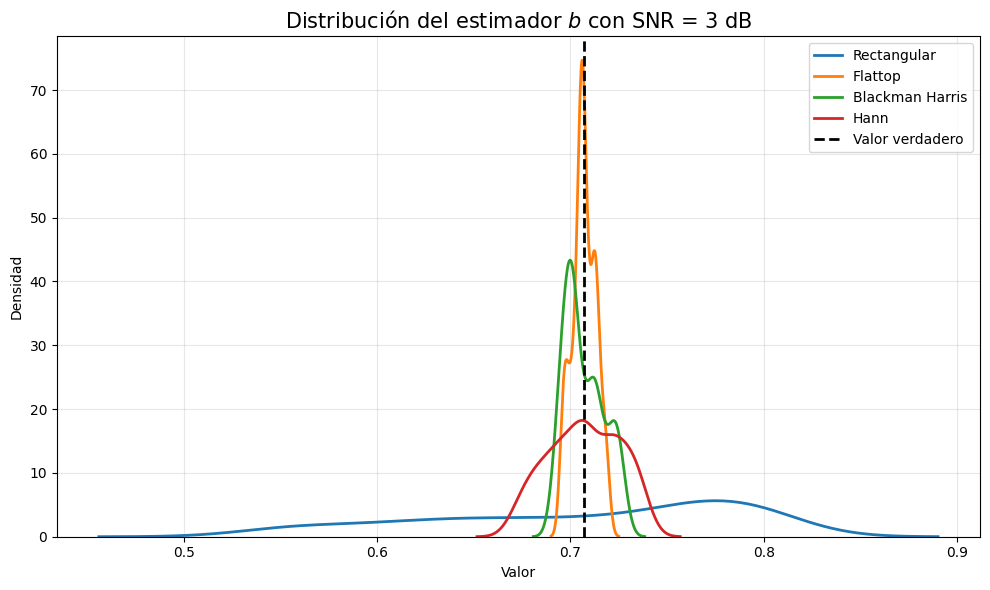

In [157]:
plt.figure(figsize=(10, 6))

sns.kdeplot(estimador_b_rectangular,
            linewidth=2,
            label='Rectangular')

sns.kdeplot(estimador_b_ft,
            linewidth=2,
            label='Flattop')

sns.kdeplot(estimador_b_bmh,
            linewidth=2,
            label='Blackman Harris')

sns.kdeplot(estimador_b_hann,
            linewidth=2,
            label='Hann')

plt.axvline(np.sqrt(2)/2,
            linestyle='--',
            linewidth=2,
            color='black',
            label='Valor verdadero')

plt.title('Distribución del estimador $b$ con SNR = 3 dB', fontsize=15)
plt.xlabel('Valor')
plt.ylabel('Densidad')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

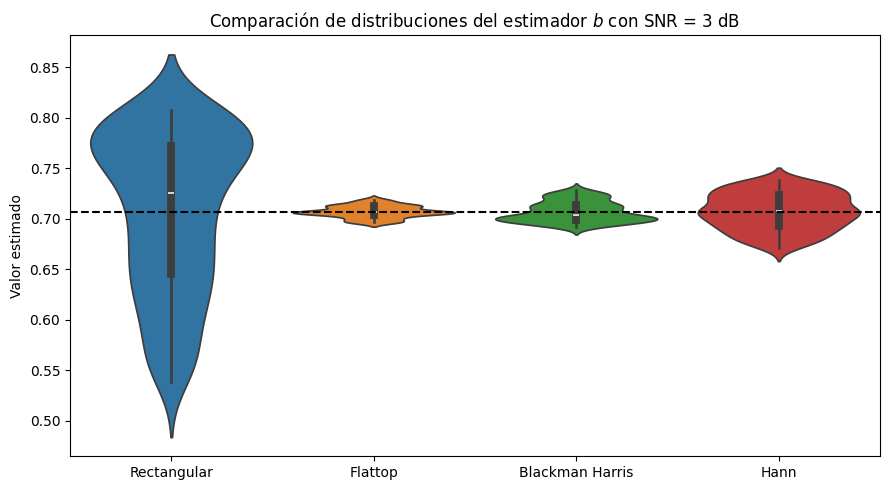

In [160]:
datos = [
    estimador_b_rectangular,
    estimador_b_ft,
    estimador_b_bmh,
    estimador_b_hann
]

labels = [
    'Rectangular',
    'Flattop',
    'Blackman Harris',
    'Hann'
]

plt.figure(figsize=(9, 5))

sns.violinplot(data=datos)

plt.xticks(range(4), labels)
plt.axhline(np.sqrt(2)/2,
            linestyle='--',
            color='black')

plt.ylabel('Valor estimado')
plt.title('Comparación de distribuciones del estimador $b$ con SNR = 3 dB')

plt.tight_layout()
plt.show()

Se nota con claridad que aumenta la varianza respecto al experimento anterior. Podemos comparar estos resultados con el estimador $a$:

In [161]:
import numpy as np
import pandas as pd

tabla_varianzas = pd.DataFrame(
    {
        "Rectangular": [
            np.var(estimador_a_rectangular),
            np.var(estimador_b_rectangular),
        ],
        "Flattop": [
            np.var(estimador_a_ft),
            np.var(estimador_b_ft),
        ],
        "Blackman-Harris": [
            np.var(estimador_a_bmh),
            np.var(estimador_b_bmh),
        ],
        "Hann": [
            np.var(estimador_a_hann),
            np.var(estimador_b_hann),
        ],
    },
    index=["Estimador A", "Estimador B"]
)

print(tabla_varianzas)

             Rectangular   Flattop  Blackman-Harris      Hann
Estimador A     0.056733  0.000203         0.004336  0.014859
Estimador B     0.006259  0.000035         0.000101  0.000329


Empeoraron las varianzas respecto al experimento con la SNR de 10 dB, con mucho sentido.

Se puede concluir que el estimador $b$ es mejor estimador que el $a$ para estimar energia de una señal senoidal para cualquier ventana.